EXERCICE 2 : Clustering et détection d'outliers sur un portefeuille
=====================================================================
Objectif : Segmenter un portefeuille d'assurance avec K-Means et HDBSCAN,
puis détecter les profils atypiques avec Isolation Forest et LOF.

Ce que vous allez apprendre :
- Appliquer K-Means et choisir K (elbow, silhouette)
- Utiliser HDBSCAN pour un clustering sans hyperparamètre K
- Détecter les anomalies avec Isolation Forest et LOF
- Interpréter les clusters et anomalies en termes actuariels

Pré-requis : M03_F01, M03_F05, Blocs 1-2 de ce module
Temps estimé : 15 minutes

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

## 1. DONNÉES ET PRÉPARATION

In [8]:
# =============================================================
# 1. DONNÉES ET PRÉPARATION
# =============================================================
print("=" * 60)
print("EXERCICE 2 : Clustering et détection d'outliers")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density', 'Exposure']
X = df[features].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Réduction de dimension pour visualisation
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f"Données : {X.shape[0]} assurés, {X.shape[1]} variables")
print(f"PCA : 2 composantes expliquent {pca.explained_variance_ratio_.sum():.1%} de la variance")

EXERCICE 2 : Clustering et détection d'outliers
Données : 678013 assurés, 5 variables
PCA : 2 composantes expliquent 55.7% de la variance



PARTIE 1 : K-Means — Choix du nombre de clusters
  K= 2 | Inertie=2650919 | Silhouette=0.2724
  K= 3 | Inertie=2177795 | Silhouette=0.2834
  K= 4 | Inertie=1721191 | Silhouette=0.2702
  K= 5 | Inertie=1502101 | Silhouette=0.2518
  K= 6 | Inertie=1342488 | Silhouette=0.2551
  K= 7 | Inertie=1225335 | Silhouette=0.2486
  K= 8 | Inertie=1131358 | Silhouette=0.2396
  K= 9 | Inertie=1061225 | Silhouette=0.2300
  K=10 | Inertie=1008659 | Silhouette=0.2348


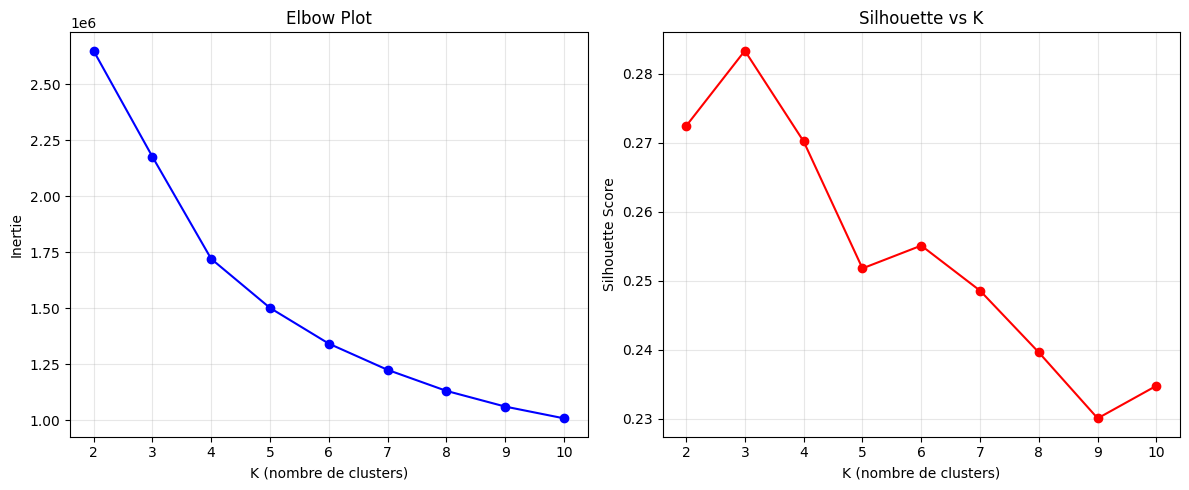


→ K optimal retenu : 4
  Silhouette score : 0.2702


In [9]:
# =============================================================
# 2. K-MEANS : CHOIX DE K
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : K-Means — Choix du nombre de clusters")
print("=" * 60)

# TODO : Tester K de 2 à 10 et stocker l'inertie et le silhouette score
# Indice :
# inertias = []
# silhouettes = []
# for k in range(2, 11):
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = km.fit_predict(X_scaled)
#     inertias.append(km.inertia_)
#     silhouettes.append(silhouette_score(X_scaled, labels))
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))
    print(f"  K={k:2d} | Inertie={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.4f}")




# TODO : Tracer le elbow plot (inertie vs K) et le silhouette plot
# Identifier le "coude" dans la courbe d'inertie
# Identifier le K qui maximise le silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('K (nombre de clusters)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Plot')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('K (nombre de clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=150)
plt.show()



# TODO : Choisir un K optimal et entraîner le modèle final
# km_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
# labels_km = km_final.fit_predict(X_scaled)
# Choix K=4 (compromis elbow + silhouette)
K_optimal = 4
km_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_scaled)
print(f"\n→ K optimal retenu : {K_optimal}")
print(f"  Silhouette score : {silhouette_score(X_scaled, labels_km, sample_size=10000, random_state=42):.4f}")



PARTIE 2 : Interprétation des clusters K-Means

Profil des clusters :
            n_assures  age_moyen  bm_moyen  veh_age  density_moy  exposure_moy  freq_sinistre
cluster_km                                                                                   
0               15441      46.89     63.20     4.40     23820.52          0.46           0.14
1              261968      48.04     52.87     4.91      1374.31          0.25           0.15
2              254048      50.86     52.38     8.67       986.60          0.90           0.07
3              146556      31.51     84.52     8.32      1615.79          0.39           0.16


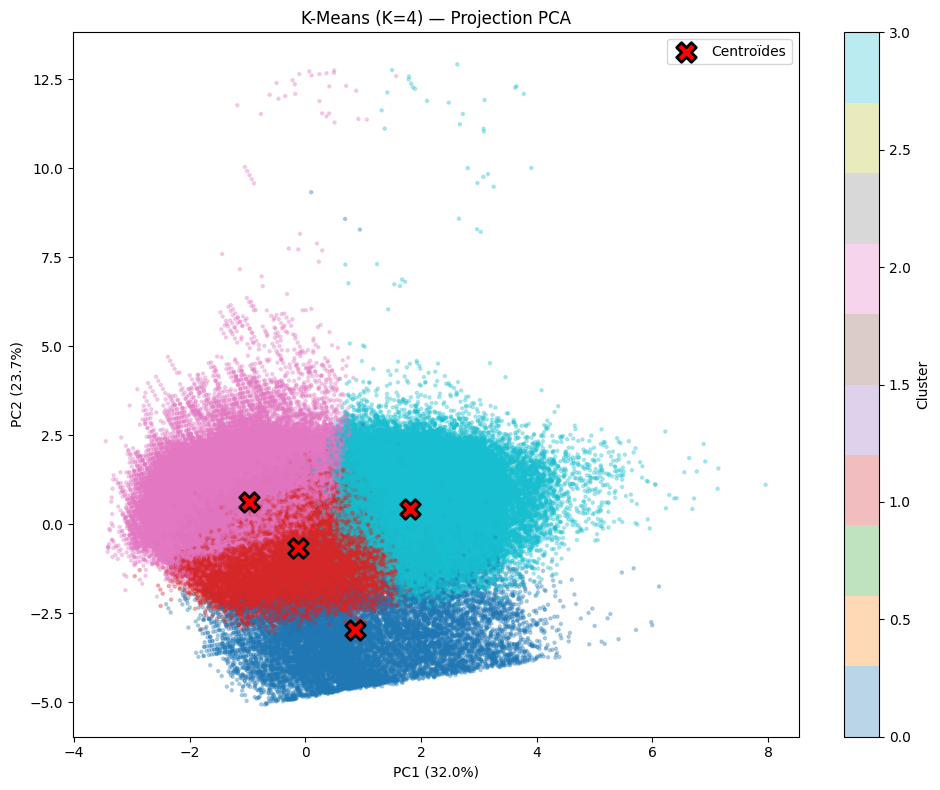

In [10]:
# =============================================================
# 3. INTERPRÉTATION DES CLUSTERS K-MEANS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Interprétation des clusters K-Means")
print("=" * 60)

# TODO : Pour chaque cluster, calculer les statistiques moyennes
# des variables originales (NON scaled)
# Indice : df.groupby(labels_km)[features].mean()


# TODO : Calculer la fréquence sinistre moyenne par cluster
# (pour voir si les clusters correspondent à des niveaux de risque)
# Indice : grouper ClaimNb/Exposure par cluster


df['cluster_km'] = labels_km

cluster_stats = df.groupby('cluster_km').agg(
    n_assures=('ClaimNb', 'count'),
    age_moyen=('DrivAge', 'mean'),
    bm_moyen=('BonusMalus', 'mean'),
    veh_age=('VehAge', 'mean'),
    density_moy=('Density', 'mean'),
    exposure_moy=('Exposure', 'mean'),
    freq_sinistre=('ClaimNb', lambda x: x.sum() / df.loc[x.index, 'Exposure'].sum())
).round(2)

print("\nProfil des clusters :")
print(cluster_stats.to_string())


# TODO : Visualiser les clusters dans le plan PCA (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_km, cmap='tab10',
                     alpha=0.3, s=5)
centers_2d = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', marker='X',
           s=200, edgecolors='black', linewidths=2, label='Centroïdes')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'K-Means (K={K_optimal}) — Projection PCA')
ax.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()



PARTIE 3 : HDBSCAN
Clusters trouvés : 972
Points de bruit (label=-1) : 420795 (62.1%)


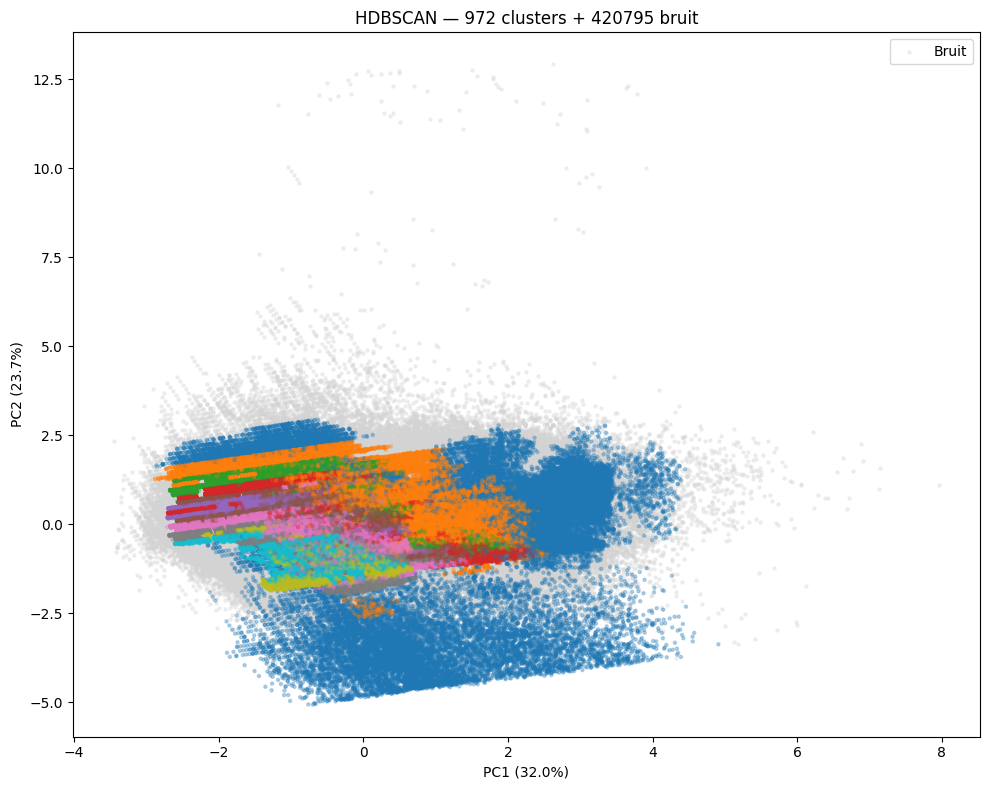


Profil clusters HDBSCAN :
                 n    age      bm   density  freq
cluster_hdb                                      
0            10348  47.55   62.50  27000.00  0.14
1              547  46.56   55.87  22612.29  0.15
2             1120  49.92   50.44  15888.40  0.13
3              411  22.14  125.01    404.34  0.56
4              123  23.12  117.05    290.14  0.34
5              124  38.06   74.88   9104.45  0.10
6              189  23.11  118.05    312.43  0.64
7              108  33.12   64.69   7092.04  0.00
8              126  24.44  112.06    255.91  0.57
9              213  30.85   70.58   8960.48  0.31
10             108  30.47   68.92   3490.77  0.13
11             101  27.20   90.01   3606.96  0.71
12            1409  51.21   50.08   8892.51  0.07
13             149  22.01   99.99   3776.92  0.68
14             194  31.23   75.81   3973.77  0.07
15             111  46.65   75.95    142.34  0.12
16             530  27.68  100.00    780.17  1.30
17             294  25.

In [11]:
# =============================================================
# 4. HDBSCAN
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : HDBSCAN")
print("=" * 60)
import hdbscan

# TODO : Appliquer HDBSCAN avec min_cluster_size=100
# Indice :
#   import hdbscan
#   clusterer = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=10)
#   labels_hdb = clusterer.fit_predict(X_scaled)

# Note : si hdbscan n'est pas installé : pip install hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=10)
labels_hdb = clusterer.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise = (labels_hdb == -1).sum()
print(f"Clusters trouvés : {n_clusters_hdb}")

# TODO : Combien de clusters ont été trouvés ?
# Combien de points sont classés comme "bruit" (label = -1) ?
print(f"Points de bruit (label=-1) : {n_noise} ({n_noise/len(labels_hdb):.1%})")

# TODO : Visualiser les clusters HDBSCAN dans le plan PCA
# Colorer les points de bruit en gris
fig, ax = plt.subplots(figsize=(10, 8))
# Points de bruit en gris
noise_mask = labels_hdb == -1
ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
            c='lightgrey', alpha=0.3, s=5, label='Bruit')
scatter = ax.scatter(X_2d[~noise_mask, 0], X_2d[~noise_mask, 1],
                        c=labels_hdb[~noise_mask], cmap='tab10', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'HDBSCAN — {n_clusters_hdb} clusters + {n_noise} bruit')
ax.legend()
plt.tight_layout()
plt.savefig("hdbscan_clusters.png", dpi=150)
plt.show()


# TODO : Comparer les clusters HDBSCAN vs K-Means
# Les deux approches trouvent-elles des structures similaires ?
    # Profil des clusters HDBSCAN
df['cluster_hdb'] = labels_hdb
hdb_stats = df[df['cluster_hdb'] >= 0].groupby('cluster_hdb').agg(
    n=('ClaimNb', 'count'),
    age=('DrivAge', 'mean'),
    bm=('BonusMalus', 'mean'),
    density=('Density', 'mean'),
    freq=('ClaimNb', lambda x: x.sum() / df.loc[x.index, 'Exposure'].sum())
).round(2)
print("\nProfil clusters HDBSCAN :")
print(hdb_stats.to_string())




PARTIE 4 : Détection d'outliers
Isolation Forest : 33901 outliers (5.0%)


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


LOF : 33899 outliers (5.0%)

Accord : 2142 outliers communs (IoU = 3.3%)

Profil Outliers (Isolation Forest) vs Normaux :
         DrivAge  BonusMalus  VehAge   Density  Exposure  ClaimNb
Normal     45.63       58.72    6.92   1218.42      0.53     0.05
Outlier    43.10       79.49    9.37  12698.40      0.47     0.09


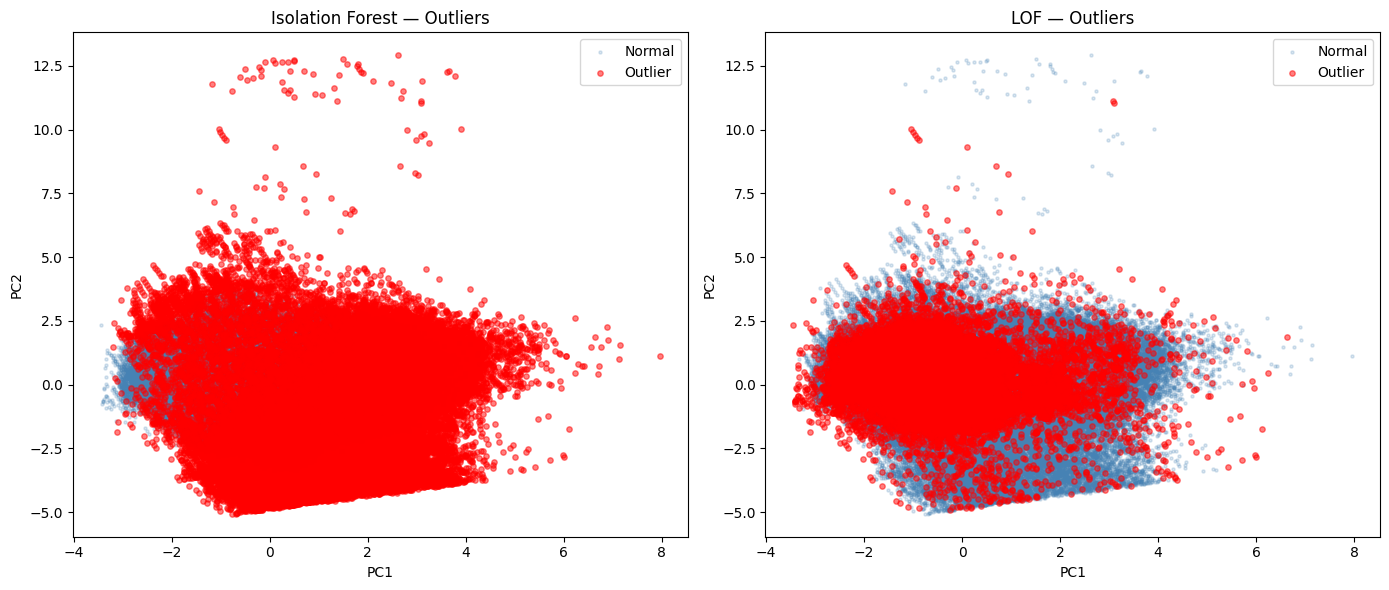

In [12]:
# =============================================================
# 5. DÉTECTION D'OUTLIERS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Détection d'outliers")
print("=" * 60)

# --- Isolation Forest ---
# TODO : Appliquer Isolation Forest avec contamination=0.05 (5% d'outliers attendus)
# Indice :
#   iso = IsolationForest(contamination=0.05, random_state=42)
#   outlier_iso = iso.fit_predict(X_scaled)  # -1 = outlier, 1 = normal
# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
outlier_iso = iso.fit_predict(X_scaled)
n_outlier_iso = (outlier_iso == -1).sum()
print(f"Isolation Forest : {n_outlier_iso} outliers ({n_outlier_iso/len(X_scaled):.1%})")



# --- LOF ---
# TODO : Appliquer LOF avec n_neighbors=20, contamination=0.05
# Indice :
#   lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
#   outlier_lof = lof.fit_predict(X_scaled)  # -1 = outlier, 1 = normal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_lof = lof.fit_predict(X_scaled)
n_outlier_lof = (outlier_lof == -1).sum()
print(f"LOF : {n_outlier_lof} outliers ({n_outlier_lof/len(X_scaled):.1%})")



# TODO : Comparer les outliers détectés par les deux méthodes
# Quel pourcentage d'accord entre Isolation Forest et LOF ?
both_outlier = ((outlier_iso == -1) & (outlier_lof == -1)).sum()
either_outlier = ((outlier_iso == -1) | (outlier_lof == -1)).sum()
print(f"\nAccord : {both_outlier} outliers communs (IoU = {both_outlier/either_outlier:.1%})")



# TODO : Analyser le profil des outliers
# Calculer les statistiques moyennes des outliers vs les normaux
# Les outliers ont-ils des caractéristiques particulières ?
# (BonusMalus très élevé ? Densité extrême ? Âge atypique ?)

# Profil des outliers vs normaux
df['outlier_iso'] = (outlier_iso == -1).astype(int)
df['outlier_lof'] = (outlier_lof == -1).astype(int)
df['outlier_both'] = ((outlier_iso == -1) & (outlier_lof == -1)).astype(int)

print("\nProfil Outliers (Isolation Forest) vs Normaux :")
profile = df.groupby('outlier_iso')[features + ['ClaimNb']].mean()
profile.index = ['Normal', 'Outlier']
print(profile.round(2))

# TODO : Visualiser les outliers dans le plan PCA
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_2d[outlier_iso == 1, 0], X_2d[outlier_iso == 1, 1],
                c='steelblue', alpha=0.2, s=5, label='Normal')
axes[0].scatter(X_2d[outlier_iso == -1, 0], X_2d[outlier_iso == -1, 1],
                c='red', alpha=0.5, s=15, label='Outlier')
axes[0].set_title('Isolation Forest — Outliers')
axes[0].legend()
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_2d[outlier_lof == 1, 0], X_2d[outlier_lof == 1, 1],
                c='steelblue', alpha=0.2, s=5, label='Normal')
axes[1].scatter(X_2d[outlier_lof == -1, 0], X_2d[outlier_lof == -1, 1],
                c='red', alpha=0.5, s=15, label='Outlier')
axes[1].set_title('LOF — Outliers')
axes[1].legend()
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig("outliers_comparison.png", dpi=150)
plt.show()



PARTIE 5 : Scoring d'anomalie


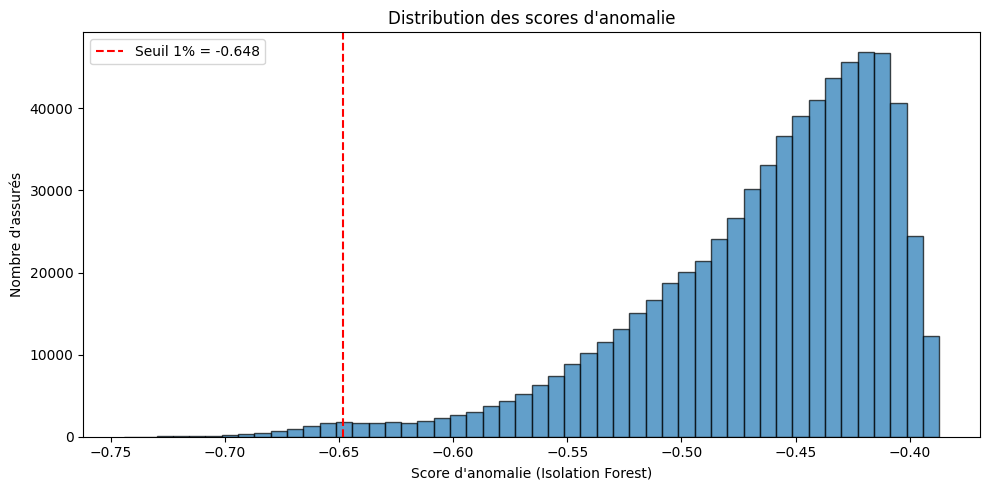


Fréquence sinistre — Top 1% anomalies : 0.1553
Fréquence sinistre — Population totale : 0.1007
Ratio : 1.54x la moyenne


In [15]:
# =============================================================
# 6. APPLICATION ACTUARIELLE : SCORING D'ANOMALIE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Scoring d'anomalie")
print("=" * 60)

# TODO : Utiliser le score d'anomalie d'Isolation Forest (score_samples)
# Plus le score est négatif, plus le point est anormal
# Indice : scores = iso.score_samples(X_scaled)

scores = iso.score_samples(X_scaled)
df['anomaly_score'] = scores


# TODO : Tracer la distribution des scores d'anomalie
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores, bins=50, edgecolor='black', alpha=0.7)
threshold = np.percentile(scores, 1)
ax.axvline(x=threshold, color='red', linestyle='--', label=f'Seuil 1% = {threshold:.3f}')
ax.set_xlabel('Score d\'anomalie (Isolation Forest)')
ax.set_ylabel('Nombre d\'assurés')
ax.set_title('Distribution des scores d\'anomalie')
ax.legend()
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=150)
plt.show()



# TODO : Parmi les 1% les plus anormaux, calculer la fréquence sinistre
# Est-ce que les "anomalies" sont aussi des profils à risque ?
# Top 1% anomalies
top1_mask = scores <= np.percentile(scores, 1)
freq_top1 = df.loc[top1_mask, 'ClaimNb'].sum() / df.loc[top1_mask, 'Exposure'].sum()
freq_all = df['ClaimNb'].sum() / df['Exposure'].sum()

print(f"\nFréquence sinistre — Top 1% anomalies : {freq_top1:.4f}")
print(f"Fréquence sinistre — Population totale : {freq_all:.4f}")
print(f"Ratio : {freq_top1/freq_all:.2f}x la moyenne")



## QUESTIONS DE RÉFLEXION

In [14]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Le K-Means avec K=4 donne-t-il des segments "interprétables" 
   pour un actuaire ? Pouvez-vous nommer chaque cluster ?
   (ex: "jeunes urbains", "seniors ruraux", etc.)

2. HDBSCAN trouve-t-il plus ou moins de clusters que K-Means ?
   Les points de "bruit" sont-ils des outliers intéressants ?

3. Les outliers détectés par Isolation Forest sont-ils les mêmes
   que ceux de LOF ? Quand utiliser l'un vs l'autre ?

4. Les anomalies détectées correspondent-elles à des profils
   potentiellement frauduleux ? Ou simplement à des assurés atypiques ?

5. Comment intégreriez-vous le score d'anomalie dans un processus
   de tarification ou de souscription ?
   (ex: flag automatique, exclusion, tarification manuelle)

6. Quelle est la limite de la détection non supervisée par rapport
   à un modèle supervisé de fraude (si on avait des labels) ?
"""

'\n1. Le K-Means avec K=4 donne-t-il des segments "interprétables" \n   pour un actuaire ? Pouvez-vous nommer chaque cluster ?\n   (ex: "jeunes urbains", "seniors ruraux", etc.)\n\n2. HDBSCAN trouve-t-il plus ou moins de clusters que K-Means ?\n   Les points de "bruit" sont-ils des outliers intéressants ?\n\n3. Les outliers détectés par Isolation Forest sont-ils les mêmes\n   que ceux de LOF ? Quand utiliser l\'un vs l\'autre ?\n\n4. Les anomalies détectées correspondent-elles à des profils\n   potentiellement frauduleux ? Ou simplement à des assurés atypiques ?\n\n5. Comment intégreriez-vous le score d\'anomalie dans un processus\n   de tarification ou de souscription ?\n   (ex: flag automatique, exclusion, tarification manuelle)\n\n6. Quelle est la limite de la détection non supervisée par rapport\n   à un modèle supervisé de fraude (si on avait des labels) ?\n'